## 1. Preprocessing Data

2 ways to look at the data:
1. yield (lbs/ft) over season
2. rate (lbs/ft/day) over season

Rate is noisy as we don't have direct measurements and yield samples can be over various times. They are not consistently taken.
The day of season (i.e. date) is intended to act as a proxy for environemental factors (amount of light, temperature).
Building off from the fake Bayesian approach, modeling the kelp's growth rate based on the day of season makes more sense for a
global/universal curve across all farms than a yield model based on the day of season. Yield varies significantly per farm per day
but their growth rate could be more similar. These are related. And, the derivative of the yield curve should look similar to the
rate curve.
GreenWave advises their farmers that an earlier outplanting date usually means a better harvest outcome. They also note that 
waiting too long to harvest can result in increased biofouling as the water warms in summer and invites more pests that harm the kelp.
However, we lack data about kelp after harvesting.


Sample is a foot of line. Farmers are instructed to take ~3 samples across their farm every month.
These same day samples carries information on measurement or biological noise which could inform the noise around the model's prediction/curve.
Also, it gives you more information about where the growth/yield could be going in the future, some level of uncertainity about the belief.
Harvest is what actually comes off the line and is at least 100 ft more than a sample.
GreenWave is interested in improving their biomass estimation where they tend to overestimate harvest.
Both samples and harvests are selected by the farmer but at very different scales. Both can be
represented as lbs/ft but need to "rescale" or "calibrate" harvest based on a factor learned from
comparing sample yields to harvest yields. A factor will be learned per farms as some farms may take
"better" samples that are more representative of the kelp's biomass while others tend to pick their
"best" kelp lines to sample which may bias the biomass estimation.


We will be organizing the data into groups of same farm-season-species with their events (observations) of lbs/ft
- outplant = 0 lbs/ft
- sample = weight / 1 ft
- harvest = weight / line length (scaled to sample if on the same plot)

Sugar kelp will be the only species analyzed. It's the most farmed species amongst all GreenWave farms.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import gaussian_kde, lognorm, norm, truncnorm
from scipy.stats import t as student_t


# greenwave is the src/ package, installed editable (`uv pip install -e .`),
# so these resolve from any working directory -- no sys.path juggling
from greenwave.preprocess_data import build_events
from greenwave.constants import GROUP, MODEL_SPECIES, MIN_FARMS_PER_REGION, LINE_TOLERANCE
from greenwave.curves import logistic, gompertz, CURVES
from greenwave.fit_curve import fit_one_season_to_curve, build_parameter_cloud
from greenwave.plotting import plot_fits, plot_cloud, plot_prior, plot_prior_curves
from greenwave.bayesian import (make_prior_kde, posterior_mcmc, make_prior_for_farm,
                                sample_prior, harvest_scale)

In [2]:
XLSX = "/Users/gracegibson/work/green_wave/greenwave/20260724_kcf_export_anonymized.xlsx"
events = build_events(XLSX)

### Filter events

We keep groups with multiple outplanting dates because it's common, and we already can't detangle
outplant lines to samples to harvests. A single harvest event is likely a mixture of outplant lines,
and even if it's only one outplant line, there's no tag to link them. Samples could be taken from
the same outplanted line or multiple lines but may not cover all possible lines. Therefore, 
both samples and harvests are a blend of all outplanted lines.

We do not drop "outlier" observations - very high or low yields per a farm season because the data
is the true observation, and the model is what we're uncertain about in bayesian statistics.
We also keep all region (== state) in the data. GreenWave advised to remove farm seasons where their
region had 2 or less farms. That advice can be applied when using a hierarchical model where the
prior can be conditioned on the observations from past farm-seasons from the same region given the
region has enough farms.

In [3]:
# filter events (message, flag from the events table)
FILTERS = [
    (f"species == {MODEL_SPECIES}", "flag_model_species"),
    ("group has an outplanting log", "flag_has_outplant_date"),
    ("harvest line <= outplant - loss", "flag_harvest_within_available"),
    ("event after seed date", "flag_after_seed"),
]

print(f"total:    {len(events)} events  {events.groupby(GROUP).ngroups} groups")
for name, flag_col in FILTERS:
    events = events[events[flag_col]]
    print(f"{name:38s} {len(events):5d} events "
            f"{events.groupby(GROUP).ngroups:4d} groups")

total:    2654 events  281 groups
species == sugar_kelp                   1778 events  166 groups
group has an outplanting log            1775 events  165 groups
harvest line <= outplant - loss         1564 events  155 groups
event after seed date                   1561 events  155 groups


In [4]:
YCOL = "lbs_ft"
TCOL = "day_of_season"
IDCOL = "farm_season_id"

SAMPLE_EVENT = "sample"      # value in `event` column for growth samples
HARVEST_EVENT = "harvest"    # value in `event` column for harvests
MIN_SAMPLES = 3              # skip seasons with fewer sample points than this
 
 

In [5]:
# ---------------- model configuration: every switch in one place ----------
YIELD_CURVE      = "logistic"   # "logistic" | "gompertz"
PRIOR_METHOD     = "kde"        # "kde" (smooth historical fits) | "broad" (population ranges, no fitting)
PRIOR_FALLBACK   = "broad"        # population fallback when a farm has too little history: "kde" | "broad"
C_PARAM          = "c"          # harvest scale parameterization: single multiplicative factor
STRICT_TEMPORAL  = True        # True: population fallback also drops other farms' same/later seasons
MCMC_KW          = dict(draws=1000, tune=1000, chains=2)  # every posterior is PyMC NUTS
NU               = 4            # Student-t dof: heavy tails shrug off a bad sample, 1 = cauchy distribution
save_plots_prefix = "v2"

Fitted 126 farm-seasons with logistic. 47 flagged for review.


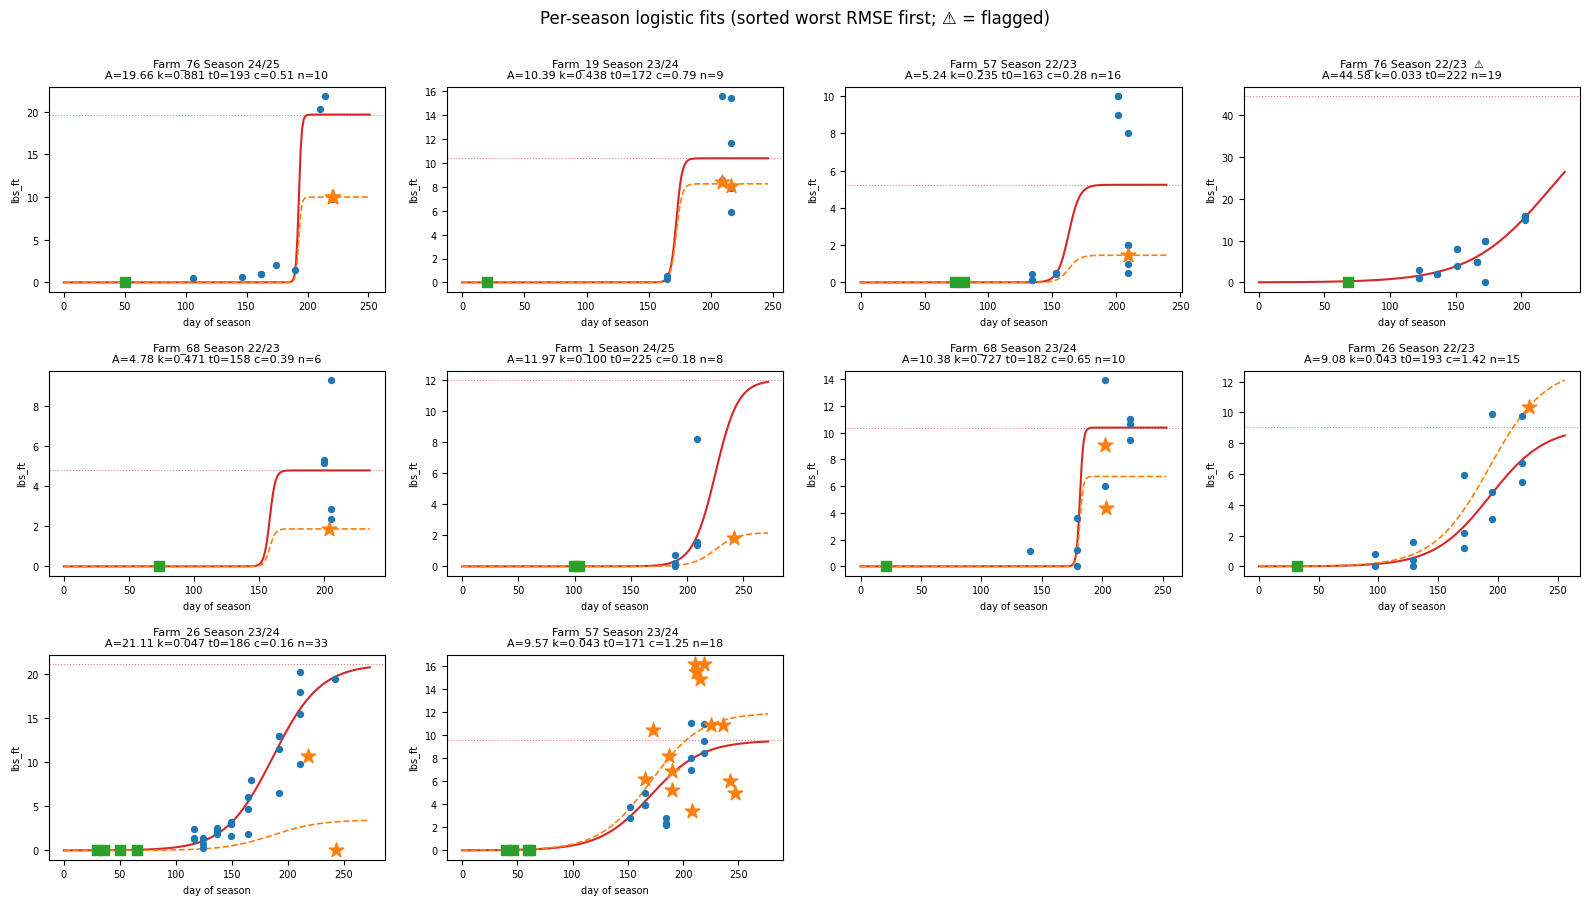

In [6]:
cloud = build_parameter_cloud(events, curve=YIELD_CURVE)
print(f"Fitted {len(cloud)} farm-seasons with {YIELD_CURVE}. "
          f"{(cloud['quality'] != 'ok').sum()} flagged for review.")
plot_fits(events, cloud, curve=YIELD_CURVE, max_plots=10,
              savepath=None)

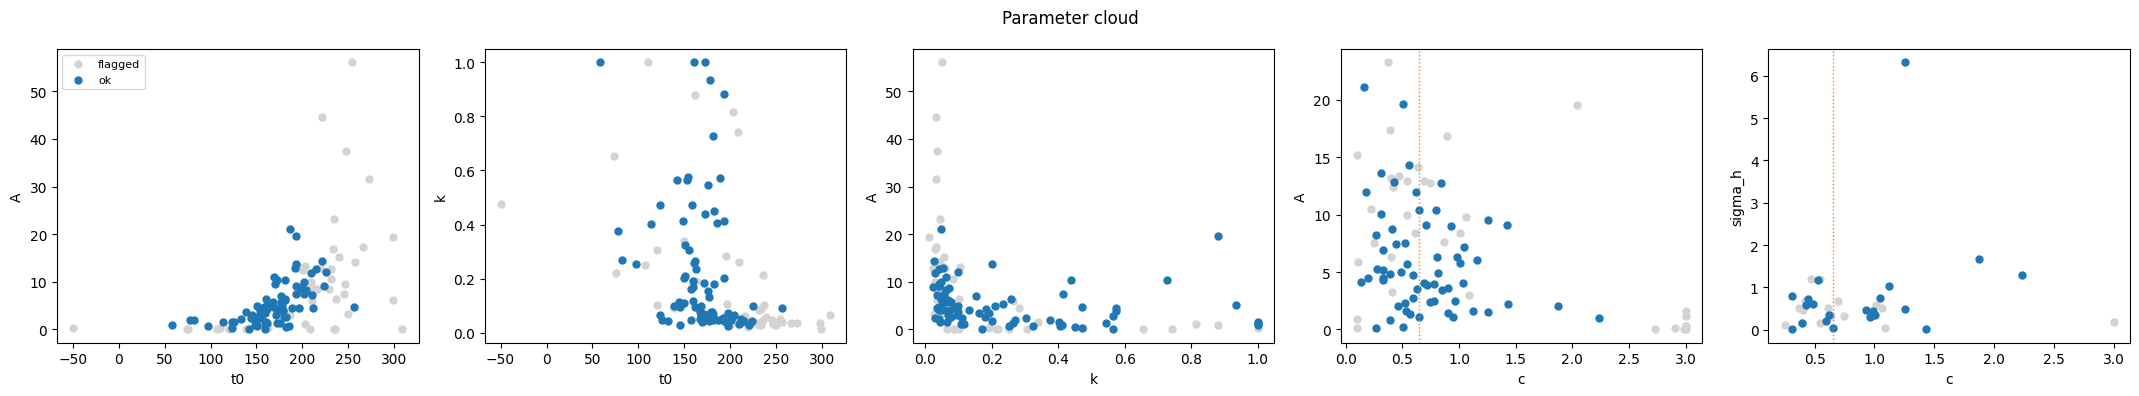

In [7]:
plot_cloud(cloud)

## 2. Prior construction

A prior here is a distribution of farm-season curve parameters with noise.

Two ways to build one (only one used, broad is a work in progress):

**`"kde"` (original approach).** Fit every historical farm-season to a curve, smooth the resulting parameter cloud with one KDE per parameter.
Centers a small Gaussian bump on each data point (farm parameter set) and sums them to get a smooth curve. 
Uses ``gaussian_kde`` that picks the bandwidth of a bump automatically. Wider bumps when data is scarce, narrower bumps when data accumulates.

When constructing a prior for a farm season, must use only historical data. Not any current or future data.

New approaches exploring with Claude:
(tried to explain the idea, implementation may not match yet)

**`"broad"` (new).** A parametric prior describing
plausible values across the whole population of farms and seasons.
Uses config to determine the prior, not the data per say. Does not depend on least-squares fits, and the season's own observations do all the narrowing. The numbers in `BROAD_PRIOR_CONFIG` are configured. Can sanity check
the ranges against `plot_cloud()` and adjust.

**Farm-specific resolution (`make_prior_for_farm`).** The prior for a target season is built from only that farm's own historical
seasons when it has at least `min_seasons` of them. No longer the global cloud of all previous farm seasons. Farms without enough history fall back to the population (`"kde"` on everyone else with the target season and "future" seasons excluded, or
`"broad"`). This is a step toward the hierarchical model. There are only 3 prior seasons to 25/26 (22/23, 23/24, 24/25). No farms have sufficient data on all 3 previous seasons and data for this current season *need to double check*.

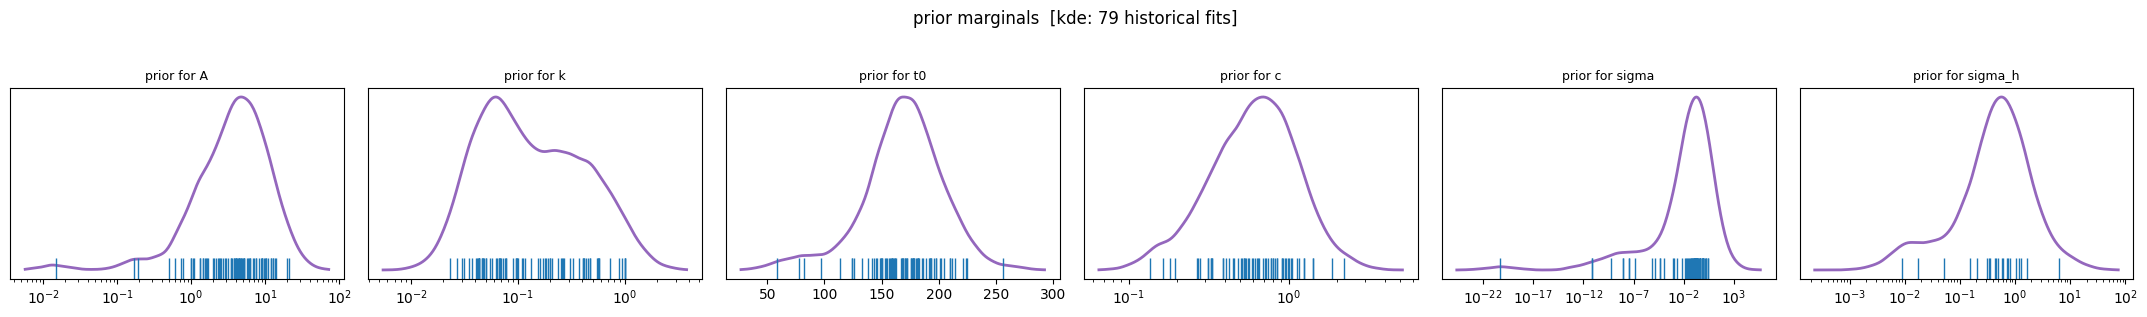

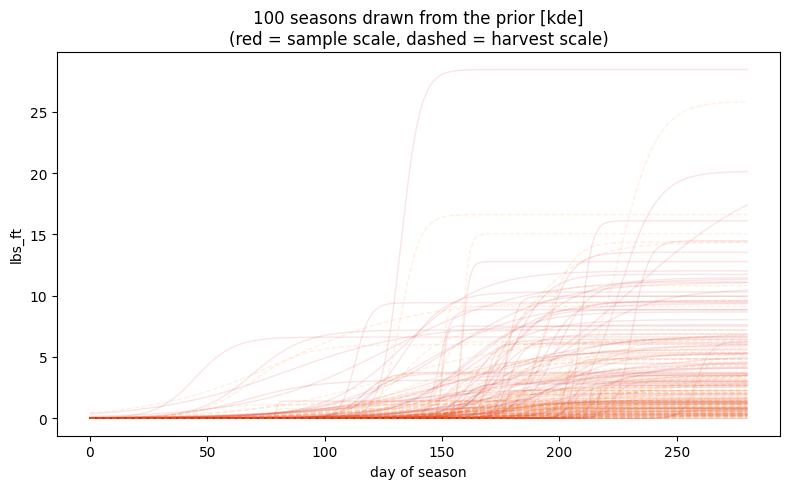

In [8]:
# population-level priors, both ways — compare them before trusting either
prior_kde   = make_prior_kde(cloud)
plot_prior(prior_kde, cloud)
plot_prior_curves(prior_kde, YIELD_CURVE)

# k steepness 
# go back to broad prior


## 4. Posterior distribution

Every posterior in this notebook is `posterior_mcmc` — PyMC NUTS.
No-U-Turn Sampler- lets the "ball" keep rolling and checks if its started curving back toward its starting point. Explores the posterior directly, but slow. KDE priors enter PyMC as `Interpolated`

Cost is one NUTS run per conditioning set, and that is what drives the
runtime of everything below: `MCMC_KW` sets draws/tune/chains for all of them.


In [9]:
# each parameter gets its own prior distribution
PARAMS_BASE = ["A", "k", "t0", "c", "sigma", "sigma_h"]
# parameters to smooth in log space, everything that is positive, non-zero values
LOG_PARAMS = {"A", "k", "c", "sigma", "sigma_h"}
def summarize(post, c_param=None, params=("A", "k", "t0")):
    """Median and 90% interval per parameter — the numbers to report."""
    c_param = c_param or C_PARAM
    vals = {p: post[p] for p in params}
    vals["harvest_scale"] = harvest_scale(post, c_param)
    for p, v in vals.items():
        v = v[np.isfinite(v)]
        if len(v) == 0:
            print(f"{p:14s}: (no information)"); continue
        lo, med, hi = np.percentile(v, [5, 50, 95])
        print(f"{p:14s}: {med:8.3f}  [{lo:.3f}, {hi:.3f}]")
    print(f"{'diagnostics':14s}: {post.get('method','?')} "
          f"rhat_max={post.get('rhat_max', np.nan):.3f} "
          f"divergences={post.get('divergences', '?')} "
          f"ess={post.get('ess', np.nan):.0f}")

## 5. Season replay & forecasting (rewired)

Same tools as before, three changes under the hood: the prior comes from
`make_prior_for_farm` (the farm's own earlier seasons when available —
never the target season), every posterior goes through `posterior_mcmc`,
and the harvest scale is read through `harvest_scale()`.

Both tools here cost one NUTS run per panel / per posterior, so
`replay_season` grids get expensive fast — keep `steps` short.
`predict_as_of` needs two (forecast without the focus day's reading, then
the belief updated with it) and reuses one when nothing was logged that day.


In [10]:
def _season_events(df, fsid):
    """(day, lbs_ft, kind, line_ft, weight_lbs) in chronological order."""
    g = df[(df["farm_season_id"] == fsid) & df["lbs_ft"].notna()
           & df["event"].isin(["sample", "harvest"])]
    ev = [(float(r["day_of_season"]), float(r["lbs_ft"]), r["event"],
           float(r.get("line_ft", np.nan)), float(r.get("weight_lbs", np.nan)))
          for _, r in g.iterrows()]
    return sorted(ev, key=lambda e: e[0])


def _split(seen):
    ts = np.array([d for d, v, ch, *_ in seen if ch == "sample"])
    ys = np.array([v for d, v, ch, *_ in seen if ch == "sample"])
    th = np.array([d for d, v, ch, *_ in seen if ch == "harvest"])
    yh = np.array([v for d, v, ch, *_ in seen if ch == "harvest"])
    return ts, ys, th, yh


def _prior_for(df, cloud, fsid, verbose=False, **kw):
    """Item-3 in one place: the prior any tool uses for a season comes
    from that farm's earlier history, never from the season itself."""
    meta = df[df["farm_season_id"] == fsid].iloc[0]
    return make_prior_for_farm(cloud, meta["Farm Name"],
                               before_season=meta["Season"],
                               method=kw.get("prior_method", PRIOR_METHOD),
                               fallback=kw.get("fallback", PRIOR_FALLBACK),
                               strict_temporal=kw.get("strict_temporal", STRICT_TEMPORAL),
                               verbose=verbose)


def _posterior_or_prior(prior, seen, curve_name, c_param, mcmc_kw=None):
    """NUTS posterior conditioned on `seen`, or the bare prior when nothing
    has been observed yet (nothing to condition on, so no sampler to run)."""
    ts, ys, th, yh = _split(seen)
    if len(ts) == 0 and len(th) == 0:
        # seeded: an unseeded prior draw makes the no-data row irreproducible
        post = sample_prior(prior, n=4000, rng=0); post["method"] = "prior"
        return post
    return posterior_mcmc(prior, curve_name, ts, ys,
                          th if len(th) else None, yh if len(yh) else None,
                          c_param=c_param, **(mcmc_kw or MCMC_KW))


def _joint_mode(post, c_param=None):
    """The single most probable parameter COMBINATION, by KDE density over
    the draws in (log A, log k, t0, log scale) space. The returned values
    are one real draw, so the implied curve is an actual sigmoid."""
    c_param = c_param or C_PARAM
    sc = harvest_scale(post, c_param)
    arrs, cols = [], []
    for name, v, logit in [("A", post["A"], True), ("k", post["k"], True),
                           ("t0", post["t0"], False), ("scale", sc, True)]:
        if name == "scale" and not np.isfinite(v).any():
            continue
        arrs.append(np.log(v) if logit else v); cols.append(name)
    X = np.vstack(arrs)
    X = X[:, np.isfinite(X).all(axis=0)]
    kde = gaussian_kde(X)
    best = X[:, np.argmax(kde(X))]
    out = {c: (float(np.exp(b)) if c != "t0" else float(b))
           for c, b in zip(cols, best)}
    out.setdefault("scale", np.nan)
    return out


def list_seasons(cloud):
    cols = ["farm_season_id", "farm", "season", "n_samples", "n_harvests",
            "quality"]
    print(cloud[cols].sort_values("n_samples", ascending=False)
          .to_string(index=False))


def show_season(df, fsid, n=None):
    events = _season_events(df, fsid)
    if n is not None:
        events = events[:n]
    print(f"{fsid}: {len(events)} observations (chronological)")
    print(f"{'#':>3s} {'day':>6s} {'lbs_ft':>8s} {'line_ft':>8s}  kind")
    for i, (d, v, ch, lf, w) in enumerate(events, 1):
        lf_txt = f"{lf:8.0f}" if np.isfinite(lf) else "       -"
        print(f"{i:3d} {d:6.1f} {v:8.2f} {lf_txt}  {ch}")


def replay_season(df, cloud, fsid, curve_name=None, steps=None, n_curves=60,
                  t_max=None, ncols=3, today=None, savepath=None, **prior_kw):
    """One panel per step: the fan of plausible yield curves narrowing as
    observations arrive. Panel 0 = the farm-aware prior.

    Costs one NUTS run per panel, so keep `steps` short.
    """
    curve_name = curve_name or YIELD_CURVE
    curve_fn = CURVES[curve_name]
    events = _season_events(df, fsid)
    if not events:
        raise ValueError(f"no observations found for {fsid}")
    if today is not None:
        events = [e for e in events if e[0] <= today]
    prior = _prior_for(df, cloud, fsid, verbose=True, **prior_kw)
    c_param = prior["_meta"]["c_param"]

    if steps is None:
        steps = list(range(len(events) + 1))
    steps = sorted(set(min(s, len(events)) for s in steps))
    all_days = [d for d, *_ in events] or [today or 200]
    if t_max is None:
        t_max = max(max(all_days) + 40, (today or 0) + 40)
    tt = np.linspace(0, t_max, 200)
    ymax_data = max([v for _, v, *_ in events], default=1.0)

    nrows = int(np.ceil(len(steps) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.2 * nrows),
                             squeeze=False, sharex=True, sharey=True)
    for ax, n_obs in zip(axes.flat, steps):
        seen = events[:n_obs]
        post = _posterior_or_prior(prior, seen, curve_name, c_param)
        sc = harvest_scale(post, c_param)
        if n_obs == 0:
            title = "prior (no data)"
        else:
            last = seen[-1]
            title = f"after {n_obs} obs (latest: {last[2]} day {last[0]:.0f})"
        for i in range(n_curves):
            y_curve = curve_fn(tt, post["A"][i], post["k"][i], post["t0"][i])
            ax.plot(tt, y_curve, color="tab:red", alpha=0.10, lw=1)
            if np.isfinite(sc[i]):
                ax.plot(tt, sc[i] * y_curve, color="tab:orange", alpha=0.08,
                        lw=1, ls="--")
        ts, ys, th, yh = _split(seen)
        if len(ts):
            ax.scatter(ts, ys, s=22, color="tab:blue", zorder=3)
        if len(th):
            ax.scatter(th, yh, marker="*", s=110, color="tab:orange", zorder=3)
        ax.set_title(title, fontsize=9)
        ax.set_ylim(0, 2.0 * ymax_data)
        if today is not None:
            ax.axvline(today, color="gray", ls=":", lw=1)
    for ax in axes.flat[len(steps):]:
        ax.axis("off")
    for ax in axes[-1, :]:
        ax.set_xlabel("day of season", fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel("lbs_ft", fontsize=8)
    fig.suptitle(f"{fsid}: plausible yield curves narrowing as observations "
                 f"arrive  [{prior['_meta']['method']} prior, mcmc]", y=1.001)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)


def predict_as_of(df, cloud, fsid, curve_name=None, today=None, n_obs=None,
                  savepath=None, **prior_kw):
    """TEXT: joint-mode sample & harvest forecast for the focus day from
    observations BEFORE it, checked against what was actually observed.
    PLOT: curves updated through the focus day.

    Needs two posteriors when something was logged ON the focus day (one
    that has not seen it, to forecast honestly; one that has, to plot the
    updated belief) and only one otherwise.
    """
    curve_name = curve_name or YIELD_CURVE
    curve_fn = CURVES[curve_name]
    all_events = _season_events(df, fsid)
    if (today is None) == (n_obs is None):
        raise ValueError("give exactly one of today= or n_obs=")
    focus_day = (all_events[min(n_obs, len(all_events) - 1)][0]
                 if n_obs is not None else today)
    prior = _prior_for(df, cloud, fsid, verbose=True, **prior_kw)
    c_param = prior["_meta"]["c_param"]

    before = [e for e in all_events if e[0] < focus_day]
    post_b = _posterior_or_prior(prior, before, curve_name, c_param)
    mode_b = _joint_mode(post_b, c_param)
    pred_s = curve_fn(focus_day, mode_b["A"], mode_b["k"], mode_b["t0"])
    pred_h = mode_b["scale"] * pred_s if np.isfinite(mode_b["scale"]) else np.nan
    fd = curve_fn(focus_day, post_b["A"], post_b["k"], post_b["t0"])
    s_lo, s_hi = np.nanpercentile(fd, [5, 95])
    hd = harvest_scale(post_b, c_param) * fd
    h_lo, h_hi = np.nanpercentile(hd[np.isfinite(hd)], [5, 95])
    bts, _, bth, _ = _split(before)
    print(f"{fsid} — day {focus_day:.0f} (forecast from {len(bts)} samples, "
          f"{len(bth)} harvests before this day):")
    print(f"  most probable sample reading:  {pred_s:.2f} lbs_ft "
          f"(90% range: {s_lo:.2f} - {s_hi:.2f})")
    print(f"  most probable harvest reading: {pred_h:.2f} lbs_ft "
          f"(90% range: {h_lo:.2f} - {h_hi:.2f})")
    for d, v, ch, *_ in [e for e in all_events if np.isclose(e[0], focus_day)]:
        lo_, hi_ = (h_lo, h_hi) if ch == "harvest" else (s_lo, s_hi)
        verdict = ("within" if lo_ <= v <= hi_ else
                   ("ABOVE" if v > hi_ else "BELOW"))
        print(f"  observed this day: {v:.2f} lbs_ft ({ch}) -> {verdict} the predicted range")

    upto = [e for e in all_events if e[0] <= focus_day]
    # nothing logged exactly on the focus day -> `upto` is `before`, so the
    # forecast posterior already IS the updated one; re-running NUTS on an
    # identical model would only burn time
    same = len(upto) == len(before)
    post = post_b if same else _posterior_or_prior(prior, upto, curve_name, c_param)
    mode = mode_b if same else _joint_mode(post, c_param)
    sc = harvest_scale(post, c_param)
    ts, ys, th, yh = _split(upto)
    last_day = max(e[0] for e in all_events)
    tt = np.linspace(0, max(focus_day, last_day) + 40, 200)
    n_band = min(2000, len(post["A"]))
    ycurves = curve_fn(tt[None, :], post["A"][:n_band, None],
                       post["k"][:n_band, None], post["t0"][:n_band, None])
    hcurves = sc[:n_band, None] * ycurves
    yq = np.nanpercentile(ycurves, [5, 95], axis=0)
    hq = np.nanpercentile(hcurves, [5, 95], axis=0)
    y_mode = curve_fn(tt, mode["A"], mode["k"], mode["t0"])

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.fill_between(tt, yq[0], yq[1], color="tab:blue", alpha=0.13)
    ax.plot(tt, y_mode, color="tab:blue", lw=1.8,
            label="sample scale (most probable curve)")
    ax.fill_between(tt, hq[0], hq[1], color="tab:orange", alpha=0.15)
    if np.isfinite(mode["scale"]):
        ax.plot(tt, mode["scale"] * y_mode, color="tab:orange", lw=1.8,
                ls="--", label="harvest scale (most probable curve)")
    if len(ts):
        ax.scatter(ts, ys, s=28, color="navy", zorder=4, label="samples")
    if len(th):
        ax.scatter(th, yh, marker="*", s=130, color="darkorange",
                   edgecolor="k", lw=0.4, zorder=4, label="harvests")
    ax.axvline(focus_day, color="gray", ls=":", lw=1.2)
    ax.set_xlabel("day of season"); ax.set_ylabel("lbs_ft")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{fsid} — updated through day {focus_day:.0f}", fontsize=10)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    return post

## 6. Running prediction table & biomass check

One row per observation of a farm-season: the joint-mode predicted
sample and harvest lbs/ft *for that day, from only the observations
before it* (an honest running forecast), next to the actual reading.
Harvest rows also carry the line length, so the lbs/ft forecast becomes
pounds: `pred_biomass = pred_harvest_lbs_ft × line_ft`, compared to the
logged harvest weight, and summed to a season-total check against
`true_biomass_lbs`.

`season_forecast_rows` computes these rows and section 7 scores the same
ones, so the forecast is defined once. Its posteriors are cached
(`_POST_CACHE`), which is why re-running this cell returns immediately —
call `_POST_CACHE.clear()` after changing the prior config or refiltering
`events`.


In [11]:
def naive_lbs_ft(seen, day):
    """GreenWave's current approach: the most recent observation's lbs/ft
    (the average when several were taken on that same most-recent day)."""
    prior_obs = [(d, v) for d, v, *_ in seen if d < day]
    if not prior_obs:
        return np.nan
    last_day = max(d for d, _ in prior_obs)
    return float(np.mean([v for d, v in prior_obs if d == last_day]))


def _point_estimate(post, curve_name, day, c_param, point="median"):
    """Reduce a posterior to one predicted sample & harvest lbs/ft for `day`.

    point= chooses the estimator of the predicted value:
      "median"     - posterior median of f(day) (minimizes absolute error;
                     the right choice when the score is MAE)
      "mean"       - posterior mean (minimizes squared error)
      "joint_mode" - the single most probable CURVE's value (best for
                     display/interpretation, measurably worse for MAE)

    This is pure arithmetic on draws — no sampling. Keeping it separate from
    the posterior is what lets ONE posterior serve both the display table
    (joint_mode) and the backtest (median) instead of one NUTS run each.
    """
    f = CURVES[curve_name]
    if point == "joint_mode":
        mode = _joint_mode(post, c_param)
        pred_s = f(day, mode["A"], mode["k"], mode["t0"])
        pred_h = (mode["scale"] * pred_s if np.isfinite(mode["scale"])
                  else np.nan)
        return float(pred_s), float(pred_h)
    agg = np.nanmedian if point == "median" else np.nanmean
    fd = f(day, post["A"], post["k"], post["t0"])
    hd = harvest_scale(post, c_param) * fd
    return float(agg(fd)), (float(agg(hd)) if np.isfinite(hd).any() else np.nan)


def _forecast(prior, curve_name, seen, day, c_param, mcmc_kw=None,
              point="median"):
    """Sample & harvest lbs/ft prediction for `day` from the observations
    in `seen`, plus the posterior they came from."""
    post = _posterior_or_prior(prior, seen, curve_name, c_param, mcmc_kw)
    pred_s, pred_h = _point_estimate(post, curve_name, day, c_param, point)
    return pred_s, pred_h, post


# ---------------------------------------------------------------------------
# One running forecast per season, sampled once and shared
# ---------------------------------------------------------------------------
# Posteriors are memoized on everything that determines them, so the
# prediction table (section 6) and the backtest (section 7) reuse each
# other's NUTS runs wherever they cover the same season, and re-running
# either cell costs nothing. Only the arrays the point estimators need are
# kept; holding full draws for every prefix of every season would be
# hundreds of MB.
#
# The key does NOT cover `df` itself, or anything read at sample time from
# module state (BROAD_PRIOR_CONFIG, NU, the curve definitions). Call
# _POST_CACHE.clear() after changing any of those, or after re-filtering
# `events`.
_POST_CACHE = {}
_KEEP = ("A", "k", "t0", "c")
_DIAG = ("method", "rhat_max", "divergences", "ess")


def _posterior_for_prefix(fsid, events, n_seen, prior, curve_name, c_param,
                          mcmc_kw=None):
    """Posterior for `fsid` given its first `n_seen` observations, memoized."""
    key = (fsid, n_seen, len(events), curve_name, c_param,
           prior["_meta"]["source"],
           tuple(sorted((mcmc_kw or MCMC_KW).items())))
    if key not in _POST_CACHE:
        post = _posterior_or_prior(prior, events[:n_seen], curve_name,
                                   c_param, mcmc_kw)
        _POST_CACHE[key] = ({k: post[k] for k in _KEEP if k in post}
                            | {k: post[k] for k in _DIAG if k in post})
    return _POST_CACHE[key]


def season_forecast_rows(df, cloud, fsid, curve_name=None, c_param=None,
                         kinds=("sample", "harvest"), point="median",
                         mcmc_kw=None, verbose=True, **prior_kw):
    """The honest running forecast for one farm-season, one row per observation.

    Each row is predicted from the observations strictly BEFORE it in
    chronological order, so a row never sees the value it predicts. This is
    the single place a per-observation forecast is computed — the display
    table and the backtest are two reductions of these rows, not two
    implementations of the same forecast.

    `kinds` is what keeps the backtest affordable: it scores harvests only,
    so kinds=("harvest",) skips the sample rows' NUTS runs rather than
    computing and discarding them.

    Returns (rows, prior, meta) so callers can report prior provenance and
    season-level truth without rebuilding either.
    """
    events = _season_events(df, fsid)
    if not events:
        raise ValueError(f"no observations for {fsid}")
    meta = df[df["farm_season_id"] == fsid].iloc[0]
    prior = _prior_for(df, cloud, fsid, verbose=verbose, **prior_kw)
    curve_name = curve_name or YIELD_CURVE
    c_param = c_param or prior["_meta"]["c_param"]
    if verbose:
        print(f"{fsid}: prior <- {prior['_meta']['source']} "
              f"[{c_param}, posterior=mcmc, point={point}]")

    rows = []
    for n, (day, actual, kind, line_ft, weight) in enumerate(events):
        if kind not in kinds:
            continue
        post = _posterior_for_prefix(fsid, events, n, prior, curve_name,
                                     c_param, mcmc_kw)
        pred_s, pred_h = _point_estimate(post, curve_name, day, c_param, point)
        nv = naive_lbs_ft(events[:n], day)
        row = dict(obs=n + 1, day=day, kind=kind, line_ft=line_ft,
                   pred_sample_lbs_ft=pred_s, pred_harvest_lbs_ft=pred_h,
                   naive_lbs_ft=nv, actual_lbs_ft=actual)
        if kind == "harvest" and np.isfinite(line_ft):
            # an lbs/ft forecast only becomes actionable as pounds off the line
            row.update(pred_biomass_lbs=pred_h * line_ft,
                       naive_biomass_lbs=nv * line_ft,
                       actual_biomass_lbs=weight)
        rows.append(row)
    return pd.DataFrame(rows), prior, meta


def season_prediction_table(df, cloud, fsid, point="joint_mode", verbose=True,
                            **kw):
    """One row per observation: the predicted sample and harvest lbs/ft for
    that day computed from all observations BEFORE it, next to what was
    actually measured.

    Harvest rows also get predicted vs actual biomass:
        pred_biomass_lbs   = pred_harvest_lbs_ft * line_ft
        actual_biomass_lbs = logged harvest weight
    and the whole season is summarized against true_biomass_lbs.
    """
    table, _prior, meta = season_forecast_rows(df, cloud, fsid, point=point,
                                               verbose=verbose, **kw)
    ft_cols = [c for c in table.columns if c.endswith("_lbs_ft")]
    table[ft_cols] = table[ft_cols].round(3)
    lb_cols = [c for c in table.columns if c.endswith("_biomass_lbs")]
    table[lb_cols] = table[lb_cols].round(1)

    h = table[table["kind"] == "harvest"]
    if len(h) and "pred_biomass_lbs" in h:
        pred_total = h["pred_biomass_lbs"].sum()
        true_total = float(meta.get("true_biomass_lbs", np.nan))
        if not np.isfinite(true_total):
            true_total = float(h["actual_biomass_lbs"].sum())
        if verbose:
            print(f"  season biomass: predicted {pred_total:,.0f} lbs vs "
                  f"actual {true_total:,.0f} lbs "
                  f"({100 * (pred_total - true_total) / true_total:+.1f}%)")
    return table


## 7. Backtest: MAE across all test seasons vs the naive baseline

For every season with harvests (and ≥ `MIN_SAMPLES` samples): forecast
each harvest event's lbs/ft from observations strictly before that
harvest day, convert to pounds via the event's line length, sum to a
season total, and compare to the true harvested biomass. The **naive
baseline is GreenWave's current approach** — the most recent
observation's lbs/ft (averaging when several land on the same day)
applied to the same line lengths — given exactly the same information
at each harvest. Priors come from `make_prior_for_farm`, so each test
season is predicted without its own data (and, with
`strict_temporal=True`, without any other farm's same-or-later
seasons).

This is the slow cell: one NUTS run per harvest event, ~250 over the
default test set, and harvest rows condition on most of a season's
history so they sample roughly twice as slowly as a bare sample row.
Expect ~10 min cold, instant on a re-run (cached). While iterating, pass
`test_fsids=[...]` or a smaller `mcmc_kw`.


In [12]:
def evaluate_biomass_mae(df, cloud, curve_name=None, c_param=None,
                         test_fsids=None, min_samples=3, mcmc_kw=None,
                         point="median", verbose=False, **prior_kw):
    """Backtest every season that has harvests: for each harvest event,
    forecast its lbs/ft from observations strictly before that day, turn
    it into pounds via the harvest's line length, and compare season
    totals to the truth.  The naive baseline gets the same information.

    This is `season_forecast_rows(kinds=("harvest",))` scored per season —
    the same forecast the prediction table displays, reduced differently
    rather than recomputed. Restricting to harvest rows is what keeps it
    affordable: it is already one NUTS run per harvest event (~250 over the
    default test set), and sample rows would quadruple that for numbers
    nothing here scores.

    Returns (per_season_table, summary_dict).
    """
    if test_fsids is None:
        counts = (df[df["event"] == "sample"].groupby("farm_season_id").size())
        with_h = set(df[(df["event"] == "harvest")
                        & df["weight_lbs"].notna()
                        & df["line_ft"].notna()]["farm_season_id"])
        test_fsids = sorted(set(counts[counts >= min_samples].index) & with_h)
    need = ["pred_biomass_lbs", "naive_biomass_lbs", "actual_biomass_lbs"]
    rows = []
    for fsid in test_fsids:
        fc, prior, meta = season_forecast_rows(
            df, cloud, fsid, curve_name=curve_name, c_param=c_param,
            kinds=("harvest",), point=point, mcmc_kw=mcmc_kw,
            verbose=verbose, **prior_kw)
        if not set(need) <= set(fc.columns):
            continue  # no harvest event carried a usable line length
        scored = fc.dropna(subset=need)
        if scored.empty:
            continue
        pred_m = scored["pred_biomass_lbs"].sum()
        pred_n = scored["naive_biomass_lbs"].sum()
        actual = scored["actual_biomass_lbs"].sum()
        rows.append(dict(farm_season_id=fsid, farm=meta["Farm Name"],
                         season=meta["Season"], n_harvests=len(scored),
                         actual_lbs=actual, model_pred_lbs=pred_m,
                         naive_pred_lbs=pred_n,
                         model_abs_err=abs(pred_m - actual),
                         naive_abs_err=abs(pred_n - actual),
                         prior_source=prior["_meta"]["source"]))
    table = pd.DataFrame(rows)
    if not len(table):
        return table, {}
    summary = dict(
        n_seasons=len(table),
        model_mae_lbs=table["model_abs_err"].mean(),
        naive_mae_lbs=table["naive_abs_err"].mean(),
        # % metrics only over seasons with nonzero actuals (a zero-lbs
        # season makes the ratio infinite without being informative)
        model_mae_pct=(table.loc[table["actual_lbs"] > 0, "model_abs_err"]
                       / table.loc[table["actual_lbs"] > 0, "actual_lbs"]).median() * 100,
        naive_mae_pct=(table.loc[table["actual_lbs"] > 0, "naive_abs_err"]
                       / table.loc[table["actual_lbs"] > 0, "actual_lbs"]).median() * 100,
        seasons_model_wins=int((table["model_abs_err"] < table["naive_abs_err"]).sum()),
    )
    summary["improvement_pct"] = 100 * (1 - summary["model_mae_lbs"]
                                        / summary["naive_mae_lbs"])
    print(f"Backtest over {summary['n_seasons']} seasons "
          f"[prior={prior_kw.get('prior_method', PRIOR_METHOD)}, posterior=mcmc, "
          f"{c_param or C_PARAM}, point={point}]")
    print(f"  model MAE: {summary['model_mae_lbs']:,.0f} lbs "
          f"(median {summary['model_mae_pct']:.1f}% of actual)")
    print(f"  naive MAE: {summary['naive_mae_lbs']:,.0f} lbs "
          f"(median {summary['naive_mae_pct']:.1f}% of actual)")
    print(f"  improvement: {summary['improvement_pct']:+.1f}%   "
          f"model closer in {summary['seasons_model_wins']}/{summary['n_seasons']} seasons")
    return table, summary


In [13]:
list_seasons(cloud)

farm_season_id    farm       season  n_samples  n_harvests quality
       F2_2324  Farm_2 Season 23/24         56           4    flag
      F25_2526 Farm_25 Season 25/26         44           1      ok
       F2_2425  Farm_2 Season 24/25         43           3    flag
       F4_2526  Farm_4 Season 25/26         36           4    flag
      F26_2324 Farm_26 Season 23/24         33           2      ok
      F25_2324 Farm_25 Season 23/24         27           7      ok
       F2_2526  Farm_2 Season 25/26         24           9      ok
      F55_2526 Farm_55 Season 25/26         23           2    flag
      F76_2223 Farm_76 Season 22/23         19           0    flag
      F70_2223 Farm_70 Season 22/23         18           1      ok
      F57_2324 Farm_57 Season 23/24         18          14      ok
      F73_2223 Farm_73 Season 22/23         17           1      ok
      F70_2324 Farm_70 Season 23/24         17           7      ok
      F12_2526 Farm_12 Season 25/26         16           2    

In [14]:
# per-season running table (item 5) — swap fsid for any season above
tbl = season_prediction_table(events, cloud, "F25_2324",
                              curve_name=YIELD_CURVE, c_param=C_PARAM,
                              prior_method=PRIOR_METHOD, fallback=PRIOR_FALLBACK,
                              strict_temporal=STRICT_TEMPORAL)
tbl

Initializing NUTS using jitter+adapt_diag...


  Farm_25: only 0 earlier seasons (< 3) -> broad population fallback
F25_2324: prior <- population (domain ranges) [c, posterior=mcmc, point=joint_mode]


Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) t

  season biomass: predicted 3,027 lbs vs actual 2,468 lbs (+22.7%)


,obs,day,kind,line_ft,pred_sample_lbs_ft,pred_harvest_lbs_ft,naive_lbs_ft,actual_lbs_ft,pred_biomass_lbs,naive_biomass_lbs,actual_biomass_lbs
0,1,122.0,sample,1.0,0.393,0.264,NaN,0.600,NaN,NaN,NaN
1,2,122.0,sample,1.0,0.624,0.356,NaN,0.050,NaN,NaN,NaN
2,3,122.0,sample,1.0,0.236,0.132,NaN,0.300,NaN,NaN,NaN
3,4,122.0,sample,1.0,0.257,0.150,NaN,0.810,NaN,NaN,NaN
4,5,137.0,sample,1.0,0.708,0.476,0.440,1.100,NaN,NaN,NaN
5,6,137.0,sample,1.0,0.933,0.665,0.440,0.800,NaN,NaN,NaN
6,7,137.0,sample,1.0,0.891,0.602,0.440,0.500,NaN,NaN,NaN
7,8,137.0,sample,1.0,0.766,0.431,0.440,0.300,NaN,NaN,NaN
8,9,149.0,sample,1.0,0.958,0.590,0.675,0.200,NaN,NaN,NaN
9,10,149.0,sample,1.0,0.733,0.438,0.675,0.500,NaN,NaN,NaN


Initializing NUTS using jitter+adapt_diag...


  Farm_25: only 1 earlier seasons (< 3) -> broad population fallback


Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...


F25_2526 — day 189 (forecast from 12 samples, 0 harvests before this day):
  most probable sample reading:  1.59 lbs_ft (90% range: 1.08 - 2.18)
  most probable harvest reading: 1.16 lbs_ft (90% range: 0.50 - 1.88)
  observed this day: 2.02 lbs_ft (sample) -> within the predicted range
  observed this day: 1.61 lbs_ft (sample) -> within the predicted range
  observed this day: 2.17 lbs_ft (sample) -> within the predicted range
  observed this day: 1.72 lbs_ft (sample) -> within the predicted range


Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


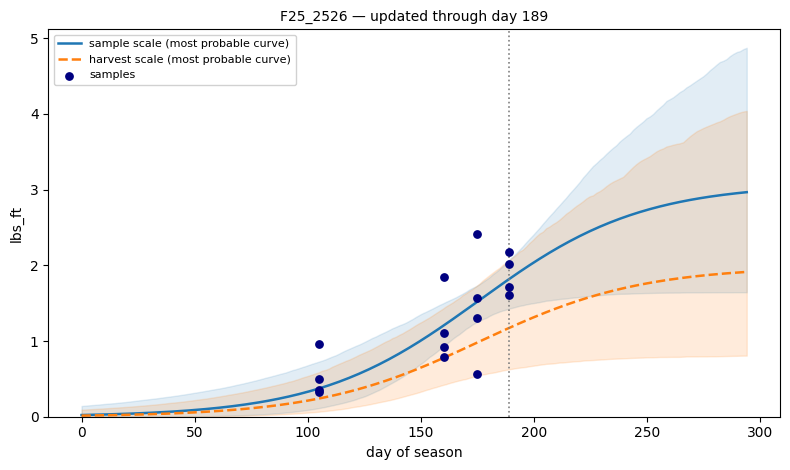

{'A': array([1.55933778, 1.44124454, 1.42210362, ..., 1.94732491, 2.86706496,
        2.98058018], shape=(2000,)),
 'k': array([0.06230426, 0.05946809, 0.07164137, ..., 0.0412302 , 0.01742841,
        0.01627383], shape=(2000,)),
 't0': array([115.93105151, 110.77908086, 104.45038267, ..., 148.93265335,
        160.41570941, 162.0634546 ], shape=(2000,)),
 'sigma': array([0.44904249, 0.45185996, 0.43953426, ..., 0.50728933, 0.41302656,
        0.39076157], shape=(2000,)),
 'c': array([0.67924232, 0.62063035, 0.81331647, ..., 0.32066222, 0.47280012,
        0.73966888], shape=(2000,)),
 'sigma_h': array([0.69925254, 0.33455874, 0.25175292, ..., 0.77653721, 0.77700503,
        0.24918327], shape=(2000,)),
 'rhat_max': 1.0088220057968316,
 'divergences': 0,
 'ess': 410.196444794516,
 'method': 'mcmc'}

In [15]:
# season replay / point-in-time forecast with the new plumbing
predict_as_of(events, cloud, "F25_2526", n_obs=15)

In [16]:
# full model prediction vs naive (item 6). One NUTS run per harvest event, so this
# is the slow cell: expect ~15 min over the full test set. Shrink it with
# test_fsids=[...] or a smaller mcmc_kw while iterating.
backtest, summary = evaluate_biomass_mae(
    events, cloud, curve_name=YIELD_CURVE, c_param=C_PARAM,
    prior_method=PRIOR_METHOD, fallback=PRIOR_FALLBACK,
    strict_temporal=STRICT_TEMPORAL, point="median")
backtest.sort_values("actual_lbs", ascending=False)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma, c, sigma_h]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [A, k, t0, sigma, c, sigma_h]
Sampling 2 chains f

Backtest over 78 seasons [prior=kde, posterior=mcmc, c, point=median]
  model MAE: 4,905 lbs (median 23.1% of actual)
  naive MAE: 5,887 lbs (median 29.3% of actual)
  improvement: +16.7%   model closer in 42/78 seasons


,farm_season_id,farm,season,n_harvests,actual_lbs,model_pred_lbs,naive_pred_lbs,model_abs_err,naive_abs_err,prior_source
47,F55_2223,Farm_55,Season 22/23,1,187541.0,147951.045583,160020.000000,39589.954417,27521.000000,population (domain ranges)
21,F2_2526,Farm_2,Season 25/26,9,86200.0,72890.022134,84243.958333,13309.977866,1956.041667,population (domain ranges)
57,F62_2324,Farm_62,Season 23/24,13,79595.0,78020.306969,86587.383333,1574.693031,6992.383333,population (domain ranges)
66,F70_2324,Farm_70,Season 23/24,7,71522.0,69422.148474,73194.500000,2099.851526,1672.500000,population (domain ranges)
29,F37_2526,Farm_37,Season 25/26,8,69610.0,65471.518813,87383.146520,4138.481187,17773.146520,population (domain ranges)
...,...,...,...,...,...,...,...,...,...,...
49,F56_2223,Farm_56,Season 22/23,1,351.0,514.398036,546.480000,163.398036,195.480000,population (domain ranges)
15,F25_2526,Farm_25,Season 25/26,1,66.0,97.218336,150.400000,31.218336,84.400000,population (domain ranges)
52,F57_2425,Farm_57,Season 24/25,1,19.0,25.163346,40.000000,6.163346,21.000000,population (domain ranges)
44,F50_2324,Farm_50,Season 23/24,1,2.2,13707.034661,4330.708800,13704.834661,4328.508800,population (domain ranges)
